In [1]:
# %% [Cell 1]: 环境配置和路径设置
 
import sys
import os
import numpy as np
import pandas as pd
import torch
import random
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image
from scipy.spatial import cKDTree
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
 
Image.MAX_IMAGE_PIXELS = None
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.dpi'] = 100
 
# ============== 路径配置 ==============
# 原始MISO路径（真正的Base，使用MLP）
ORIGINAL_PATH = '/home/graduates/XiaoYX/miso-main/miso'
# ISOGAM路径（GraphEncoder + Learnable Weights）
IMPROVED_PATH = '/home/graduates/XiaoYX/ISOGAM/miso-main'
# 数据路径
DATA_PATH = '/home/graduates/XiaoYX/ISOGAM/miso-main/tutorial/miso_tutorial_data'
 
def set_seed(seed=100):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
 
set_seed(100)
 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"{'✓ CUDA: ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else '✗ CPU'}")
print(f"路径验证: Original={os.path.exists(ORIGINAL_PATH)}, "
      f"Improved={os.path.exists(IMPROVED_PATH)}, Data={os.path.exists(DATA_PATH)}")
print("✓ Cell 1 完成")

✓ CUDA: NVIDIA GeForce RTX 4090
路径验证: Original=True, Improved=True, Data=True
✓ Cell 1 完成


In [2]:
# %% [Cell 2]: 加载数据
 
# 用改进版路径加载 preprocess（两个版本 utils 相同）
sys.path.insert(0, IMPROVED_PATH)
from miso.utils import preprocess
 
rna = sc.read(os.path.join(DATA_PATH, 'rna.h5ad'))
rna = preprocess(rna, modality='rna')
print(f"RNA:     {rna.shape}")
 
protein = sc.read(os.path.join(DATA_PATH, 'protein.h5ad'))
protein = preprocess(protein, modality='protein')
print(f"Protein: {protein.shape}")
 
image_emb = np.load(os.path.join(DATA_PATH, 'image_emb.npy'))
print(f"Image:   {image_emb.shape}")
 
locs = pd.read_csv(os.path.join(DATA_PATH, 'locs.csv'), index_col=0)
locs.columns = [str(i) for i in range(1, 6)]
print(f"Locs:    {locs.shape}")
 
print("✓ Cell 2 完成")

RNA:     (4194, 18030)
Protein: (4194, 35)
Image:   (4194, 576)
Locs:    (4194, 5)
✓ Cell 2 完成


In [3]:
# %% [Cell 3]: 预计算 pcs_50（所有实验共用，保证 ICC 比较公平）
#
# 关键设计原则：
# 三个版本（原始MISO / +GE / ISOGAM）的训练过程不同，但 ICC 评估必须用
# 同一套 pcs_50（标准化原始数据的 top-50 PCs），才能公平比较聚类质量。
# 这里统一预计算一次，后续所有实验都共用这个 pcs_50。
 
features_raw = [rna, protein, image_emb]
features_std = [StandardScaler().fit_transform(f) for f in features_raw]
GLOBAL_PCS_50 = [
    PCA(min(50, f.shape[1]), random_state=0).fit_transform(f)
    for f in features_std
]
 
print("预计算 pcs_50 完成:")
for i, (name, pcs) in enumerate(zip(['RNA', 'Protein', 'Image'], GLOBAL_PCS_50)):
    print(f"  {name}: {pcs.shape}")
print("\n✓ Cell 3 完成: pcs_50 已统一预计算（所有实验共用）")

预计算 pcs_50 完成:
  RNA: (4194, 50)
  Protein: (4194, 35)
  Image: (4194, 50)

✓ Cell 3 完成: pcs_50 已统一预计算（所有实验共用）


In [4]:
# %% [Cell 4]: 指标计算函数（ICC + Moran's I）
#
# ICC 公式（论文 Methods section）：
#     ICC_i^(k) = σ²_m / (σ²_i + σ²_m)
# 数据：GLOBAL_PCS_50（统一预计算的 top-50 PCs）
#
# Moran's I：与 tutorial.ipynb 完全一致，KNN k=6
 
def paper_icc_scalar(pcs_data, clusters):
    """与 model_tonsil._calculate_modality_icc 完全一致"""
    unique_clusters = np.unique(clusters)
    if len(unique_clusters) < 2:
        return 0.0
    D = pcs_data.shape[1]
    cluster_means = np.array([pcs_data[clusters == c].mean(axis=0)
                               for c in unique_clusters])
    sigma2_m = cluster_means.var(axis=0)          # 全局簇间方差

    sigma2_i = np.zeros(D)                         # 全局加权簇内方差
    for c in unique_clusters:
        mask = clusters == c
        sigma2_i += pcs_data[mask].var(axis=0) * mask.sum()
    sigma2_i /= len(clusters)

    denom = sigma2_i + sigma2_m
    icc_per_feature = np.where(denom > 1e-12, sigma2_m / denom, 0.0)
    return float(np.mean(icc_per_feature))
 
 
def paper_icc_distribution(pcs_data, clusters):
    """与 model_tonsil.calculate_icc_distribution 完全一致，返回 D 个 ICC 值"""
    unique_clusters = np.unique(clusters)
    if len(unique_clusters) < 2:
        return []
    D = pcs_data.shape[1]
    cluster_means = np.array([pcs_data[clusters == c].mean(axis=0)
                               for c in unique_clusters])
    sigma2_m = cluster_means.var(axis=0)

    sigma2_i = np.zeros(D)
    for c in unique_clusters:
        mask = clusters == c
        sigma2_i += pcs_data[mask].var(axis=0) * mask.sum()
    sigma2_i /= len(clusters)

    denom = sigma2_i + sigma2_m
    icc_per_feature = np.where(denom > 1e-12, sigma2_m / denom, 0.0)
    return icc_per_feature.tolist()
 
 
def calculate_morans_i(clusters, locs, n_neighbors=6):
    """
    Moran's I 空间自相关。与 tutorial.ipynb 完全一致。
    """
    coords = locs[['4', '5']].values
    n = len(clusters)
    tree = cKDTree(coords)
    _, indices = tree.query(coords, k=n_neighbors + 1)
 
    W = np.zeros((n, n))
    for i in range(n):
        W[i, indices[i, 1:]] = 1.0 / n_neighbors
 
    x = clusters.astype(float)
    x_dev = x - x.mean()
    W_sum = W.sum()
    den = x_dev @ x_dev
 
    if den < 1e-10:
        return 0.0, 0.0
 
    mi = (n / W_sum) * (x_dev @ W @ x_dev) / den
    E_I = -1.0 / (n - 1)
    S1 = 0.5 * np.sum((W + W.T) ** 2)
    S2 = np.sum((W.sum(1) + W.sum(0)) ** 2)
    n2 = n * n
    S3 = (np.sum(x_dev ** 4) / n) / ((np.sum(x_dev ** 2) / n) ** 2 + 1e-15)
    Var = ((n * ((n2-3*n+3)*S1 - n*S2 + 3*W_sum**2)
             - S3 * ((n2-n)*S1 - 2*n*S2 + 6*W_sum**2))
            / ((n-1)*(n+1)*(n+2)*W_sum**2 + 1e-15)) - E_I**2
    z = (mi - E_I) / np.sqrt(abs(Var)) if abs(Var) > 1e-15 else 0.0
 
    return mi, z
 
 
def compute_all_metrics(clusters, pcs_50_list=None):
    """
    统一计算所有指标（ICC + Moran's I）。
    pcs_50_list: 若为 None，使用 GLOBAL_PCS_50。
    """
    pcs = pcs_50_list if pcs_50_list is not None else GLOBAL_PCS_50
 
    rna_icc     = paper_icc_scalar(pcs[0], clusters)
    protein_icc = paper_icc_scalar(pcs[1], clusters)
    image_icc   = paper_icc_scalar(pcs[2], clusters)
 
    rna_dist     = paper_icc_distribution(pcs[0], clusters)
    protein_dist = paper_icc_distribution(pcs[1], clusters)
    image_dist   = paper_icc_distribution(pcs[2], clusters)
 
    morans_i, morans_z = calculate_morans_i(clusters, locs)
 
    return {
        'rna_icc':           rna_icc,
        'protein_icc':       protein_icc,
        'image_icc':         image_icc,
        'morans_i':          morans_i,
        'morans_z':          morans_z,
        'rna_icc_dist':      rna_dist,
        'protein_icc_dist':  protein_dist,
        'image_icc_dist':    image_dist,
    }
 
 
print("✓ Cell 4 完成: 指标计算函数已定义")

✓ Cell 4 完成: 指标计算函数已定义


In [5]:
# %% [Cell 5]: 模型加载函数
 
def load_original_miso():
    """加载原始 MISO（使用 MLP，来自 ORIGINAL_PATH）"""
    for mod in list(sys.modules.keys()):
        if 'miso' in mod.lower():
            del sys.modules[mod]
    if ORIGINAL_PATH in sys.path:
        sys.path.remove(ORIGINAL_PATH)
    sys.path.insert(0, ORIGINAL_PATH)
    from miso.model import Miso
    return Miso
 
 
def load_isogam_miso():
    """加载 ISOGAM（使用 GraphAutoencoder，来自 IMPROVED_PATH）"""
    for mod in list(sys.modules.keys()):
        if 'miso' in mod.lower():
            del sys.modules[mod]
    if IMPROVED_PATH in sys.path:
        sys.path.remove(IMPROVED_PATH)
    sys.path.insert(0, IMPROVED_PATH)
    from miso.model import Miso
    return Miso
 
 
def run_single_experiment(config_name, config, seed):
    """
    运行单次实验。
 
    三种版本：
      'original'  → 原始MISO（MLP，无GE无LW）
      'ge_only'   → ISOGAM代码 use_graph_encoder=True, learnable_weights=False
      'isogam'    → ISOGAM代码 use_graph_encoder=True, learnable_weights=True
 
    ICC 统一用预计算的 GLOBAL_PCS_50，保证三个版本可比。
    """
    print(f"\n  Running: {config_name}, seed={seed}")
 
    try:
        set_seed(seed)
 
        version = config['version']
        n_clusters = config['n_clusters']
 
        if version == 'original':
            # ── 原始 MISO：使用 MLP，不传任何额外参数 ─────────────────────
            MisoClass = load_original_miso()
            model = MisoClass(
                features=[rna, protein, image_emb],
                ind_views='all',
                combs='all',
                sparse=False,
                device=device
            )
            model.train()
 
        else:
            # ── ISOGAM 代码：GE / GE+LW 通过开关控制 ─────────────────────
            MisoClass = load_isogam_miso()
            model = MisoClass(
                features=[rna, protein, image_emb],
                ind_views='all',
                combs='all',
                sparse=False,
                device=device,
                use_graph_encoder=config['use_graph_encoder'],
                learnable_weights=config['learnable_weights'],
                spatial_locs=locs,
                spatial_neighbors=6
            )
            model.train()
 
        clusters = model.cluster(n_clusters=n_clusters)
        # ── 计算真实重构 Loss（三个模态分别记录，key名与Cell 8/9.5对齐）─────
        rna_recon_mse     = None
        protein_recon_mse = None
        image_recon_mse   = None
        avg_recon_mse     = None
        try:
            if hasattr(model, 'final_recon_losses') and model.final_recon_losses is not None:
                losses = model.final_recon_losses
                if len(losses) >= 3 and all(v is not None for v in losses[:3]):
                    rna_recon_mse     = float(losses[0])
                    protein_recon_mse = float(losses[1])
                    image_recon_mse   = float(losses[2])
                    avg_recon_mse     = float(np.mean([v for v in losses if v is not None]))
        except Exception as e_recon:
            print(f"    ⚠ Recon loss计算失败: {e_recon}")
 
        # ── 统一用 GLOBAL_PCS_50 计算 ICC（公平比较） ─────────────────────
        metrics = compute_all_metrics(clusters)
 
        result = {
            'config_name':  config_name,
            'seed':         seed,
            'version':      version,
            'n_clusters':   n_clusters,
            **metrics,
            'rna_recon_mse':     rna_recon_mse,
            'protein_recon_mse': protein_recon_mse,
            'image_recon_mse':   image_recon_mse,
            'avg_recon_mse':     avg_recon_mse,
            'emb':          model.emb.copy(),
            'clusters':     clusters.copy(),
            'status':       'success'
        }
 
        print(f"    ✓ RNA ICC={metrics['rna_icc']:.4f}  "
              f"Protein ICC={metrics['protein_icc']:.4f}  "
              f"Image ICC={metrics['image_icc']:.4f}  "
              f"Moran's I={metrics['morans_i']:.4f} (z={metrics['morans_z']:.2f})")
        return result
 
    except Exception as e:
        import traceback
        print(f"    ✗ Error: {e}")
        traceback.print_exc()
        return {
            'config_name': config_name, 'seed': seed,
            'version': config.get('version', ''), 'n_clusters': config.get('n_clusters', -1),
            'rna_icc': None, 'protein_icc': None, 'image_icc': None,
            'morans_i': None, 'morans_z': None,
            'rna_icc_dist': [], 'protein_icc_dist': [], 'image_icc_dist': [],
            'emb': None, 'clusters': None,
            'status': f'error: {e}'
        }
 
print("✓ Cell 5 完成: 模型加载和实验函数已定义")

✓ Cell 5 完成: 模型加载和实验函数已定义


In [6]:
# %% [Cell 6]: 消融实验配置
#
# 三步递进消融：
#   Step 1: 原始MISO（真正的Base，使用原始代码的MLP）
#   Step 2: +GraphEncoder（只加创新点1，ISOGAM代码）
#   Step 3: ISOGAM（创新点1 + 创新点2，完整方法）
#
# 这样可以分别量化两个创新点各自的贡献。
 
ABLATION_CONFIGS = {
    # ── 主实验（n_clusters=45）──────────────────────────────────────────
    'MISO_n8': {
        'version': 'original',
        'use_graph_encoder': False,
        'learnable_weights': False,
        'n_clusters': 8,
        'description': 'Original MISO (MLP, fixed weights) — True Base'
    },
    'GE_only_n8': {
        'version': 'ge_only',
        'use_graph_encoder': True,
        'learnable_weights': False,
        'n_clusters': 8,
        'description': '+GraphEncoder (Innovation 1 only)'
    },
    'ISOGAM_n8': {
        'version': 'isogam',
        'use_graph_encoder': True,
        'learnable_weights': True,
        'n_clusters': 8,
        'description': 'ISOGAM (GE + Learnable Weights, Innovation 1+2)'
    }
}
 
RANDOM_SEEDS = [100, 110, 120, 130, 140]   # 5个种子保证统计检验可靠
 
print("消融实验配置（三步递进消融，主实验 n_clusters=8）:")
print(f"{'Config':<18} {'Version':<12} {'GE':^5} {'LW':^5} {'n_clusters':^12}")
print("-" * 55)
for name, cfg in ABLATION_CONFIGS.items():
    ge = '✓' if cfg.get('use_graph_encoder') else '✗'
    lw = '✓' if cfg.get('learnable_weights') else '✗'
    print(f"  {name:<16} {cfg['version']:<12} {ge:^5} {lw:^5} {cfg['n_clusters']:^12}")
print(f"\n随机种子: {RANDOM_SEEDS}")
print("\n✓ Cell 6 完成")

消融实验配置（三步递进消融，主实验 n_clusters=8）:
Config             Version       GE    LW    n_clusters 
-------------------------------------------------------
  MISO_n8          original       ✗     ✗        8      
  GE_only_n8       ge_only        ✓     ✗        8      
  ISOGAM_n8        isogam         ✓     ✓        8      

随机种子: [100, 110, 120, 130, 140]

✓ Cell 6 完成


In [7]:
# %% [Cell 7]: 运行所有消融实验
 
output_dir = './ablation_outputs'
os.makedirs(output_dir, exist_ok=True)
 
print("=" * 70)
print("Cell 7: Running Ablation Experiments")
print("  Base:  原始MISO（ORIGINAL_PATH，MLP）")
print("  Step2: +GraphEncoder（IMPROVED_PATH，GE only）")
print("  Step3: ISOGAM（IMPROVED_PATH，GE + LW）")
print("  ICC:   统一用 GLOBAL_PCS_50（论文公式）")
print("  Moran: KNN k=6")
print("=" * 70)
 
ablation_results = []
 
for config_name, config in ABLATION_CONFIGS.items():
    print(f"\n【{config_name}】 — {config['description']}")
    for seed in RANDOM_SEEDS:
        result = run_single_experiment(config_name, config, seed)
        ablation_results.append(result)
 
# ── 汇总打印 ──────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("实验汇总")
print("=" * 70)
 
results_flat = [
    {k: v for k, v in r.items()
     if k not in ('rna_icc_dist', 'protein_icc_dist', 'image_icc_dist',
                  'emb', 'clusters')}
    for r in ablation_results
]
results_df = pd.DataFrame(results_flat)
 
for cfg_name in ABLATION_CONFIGS:
    sub = results_df[(results_df['config_name'] == cfg_name) &
                     (results_df['status'] == 'success')]
    if len(sub) == 0:
        continue
    print(f"\n  {cfg_name}  (n={len(sub)})")
    print(f"    RNA ICC:     {sub['rna_icc'].mean():.4f} ± {sub['rna_icc'].std():.4f}")
    print(f"    Protein ICC: {sub['protein_icc'].mean():.4f} ± {sub['protein_icc'].std():.4f}")
    print(f"    Image ICC:   {sub['image_icc'].mean():.4f} ± {sub['image_icc'].std():.4f}")
    print(f"    Moran's I:   {sub['morans_i'].mean():.4f} ± {sub['morans_i'].std():.4f}")
 
results_df.to_csv(os.path.join(output_dir, 'ablation_raw_results.csv'), index=False)
print(f"\n✓ 原始结果已保存: {output_dir}/ablation_raw_results.csv")
print("=" * 70)
print("Cell 7 完成!")

Cell 7: Running Ablation Experiments
  Base:  原始MISO（ORIGINAL_PATH，MLP）
  Step2: +GraphEncoder（IMPROVED_PATH，GE only）
  Step3: ISOGAM（IMPROVED_PATH，GE + LW）
  ICC:   统一用 GLOBAL_PCS_50（论文公式）
  Moran: KNN k=6

【MISO_n8】 — Original MISO (MLP, fixed weights) — True Base

  Running: MISO_n8, seed=100


GraphAE training modality 1/3:   0%|          | 0/1000 [00:00<?, ?it/s]

GraphAE training modality 2/3:   0%|          | 0/1000 [00:00<?, ?it/s]

GraphAE training modality 3/3:   0%|          | 0/1000 [00:00<?, ?it/s]

    ✓ RNA ICC=0.1066  Protein ICC=0.1554  Image ICC=0.1026  Moran's I=0.5931 (z=67.38)

  Running: MISO_n8, seed=110


...

Attention-based modality quality weights (trained on embedding variance):
  rna: 2.7260
  protein: 0.1335
  image_emb: 0.1405
Final learned modality weights:
  rna: 1.0000
  protein: 1.0000
  image_emb: 1.0000
    ✓ RNA ICC=0.1017  Protein ICC=0.1540  Image ICC=0.1032  Moran's I=0.7566 (z=85.94)

  Running: ISOGAM_n8, seed=140
[MISO] 空间KNN图构建完成，每spot连接最近 6 个空间邻居
Initialized learnable weights:
  rna: 1.0000
  protein: 1.0000
  image_emb: 1.0000


GraphAE training modality 1/3:   0%|          | 0/1000 [00:00<?, ?it/s]

GraphAE training modality 2/3:   0%|          | 0/1000 [00:00<?, ?it/s]

GraphAE training modality 3/3:   0%|          | 0/1000 [00:00<?, ?it/s]

Attention-based modality quality weights (trained on embedding variance):
  rna: 2.7852
  protein: 0.1019
  image_emb: 0.1129
Final learned modality weights:
  rna: 1.0000
  protein: 1.0000
  image_emb: 1.0000
    ✓ RNA ICC=0.1838  Protein ICC=0.5025  Image ICC=0.2159  Moran's I=0.5849 (z=66.44)

实验汇总

  MISO_n8  (n=5)
    RNA ICC:     0.1366 ± 0.0431
    Protein ICC: 0.2936 ± 0.1946
    Image ICC:   0.1488 ± 0.0643
    Moran's I:   0.6619 ± 0.0691

  GE_only_n8  (n=5)
    RNA ICC:     0.1525 ± 0.0421
    Protein ICC: 0.3631 ± 0.1944
    Image ICC:   0.1700 ± 0.0645
    Moran's I:   0.6450 ± 0.0684

  ISOGAM_n8  (n=5)
    RNA ICC:     0.1377 ± 0.0397
    Protein ICC: 0.3691 ± 0.2000
    Image ICC:   0.1670 ± 0.0605
    Moran's I:   0.5631 ± 0.1223

✓ 原始结果已保存: ./ablation_outputs/ablation_raw_results.csv
Cell 7 完成!


In [8]:
# Cell A
# 把消融实验的 clusters 保存下来，以后不用重跑
import os
save_dir = './ablation_outputs'
os.makedirs(save_dir, exist_ok=True)

for r in ablation_results:
    if r['status'] == 'success' and 'clusters' in r:
        fname = f"{save_dir}/{r['config_name']}_seed{r['seed']}_clusters.npy"
        np.save(fname, r['clusters'])

# 验证
saved = [f for f in os.listdir(save_dir) if f.endswith('_clusters.npy')]
print(f'已保存 {len(saved)} 个聚类结果文件到 {save_dir}/')
for f in sorted(saved):
    print(f'  {f}')

已保存 15 个聚类结果文件到 ./ablation_outputs/
  GE_only_n8_seed100_clusters.npy
  GE_only_n8_seed110_clusters.npy
  GE_only_n8_seed120_clusters.npy
  GE_only_n8_seed130_clusters.npy
  GE_only_n8_seed140_clusters.npy
  ISOGAM_n8_seed100_clusters.npy
  ISOGAM_n8_seed110_clusters.npy
  ISOGAM_n8_seed120_clusters.npy
  ISOGAM_n8_seed130_clusters.npy
  ISOGAM_n8_seed140_clusters.npy
  MISO_n8_seed100_clusters.npy
  MISO_n8_seed110_clusters.npy
  MISO_n8_seed120_clusters.npy
  MISO_n8_seed130_clusters.npy
  MISO_n8_seed140_clusters.npy


In [9]:
# Cell B 
# 加载 cell type 标注
annot_df = pd.read_csv(os.path.join(DATA_PATH, 'cell_type_annotations.csv'))
annotations = annot_df['cell_type'].values
TARGET = 'B cell (GC)'
GC_MARKERS = ['BCL6', 'AICDA', 'MKI67']
S_annot = set(np.where(annotations == TARGET)[0])
print(f'S_annot ({TARGET}): {len(S_annot)} spots')

# 加载 RNA 用于 marker 验证
rna_adata = sc.read_h5ad(os.path.join(DATA_PATH, 'rna.h5ad'))
rna_adata.var_names_make_unique()
sc.pp.normalize_total(rna_adata, target_sum=1e4)
sc.pp.log1p(rna_adata)
gene_names = list(rna_adata.var_names)
X_rna = rna_adata.X.toarray() if hasattr(rna_adata.X, 'toarray') else np.array(rna_adata.X)

def get_marker_zscore(clusters, cluster_id):
    mask = clusters == cluster_id
    if mask.sum() < 2:
        return -999
    zs = []
    for g in GC_MARKERS:
        if g in gene_names:
            idx = gene_names.index(g)
            expr = X_rna[:, idx]
            z = (expr[mask].mean() - expr.mean()) / (expr.std() + 1e-10)
            zs.append(z)
    return np.mean(zs) if zs else -999

print('✓ 标注和 RNA 数据加载完成')

S_annot (B cell (GC)): 680 spots
✓ 标注和 RNA 数据加载完成


In [10]:
# Cell C
print("=" * 65)
print("  消融实验 — Germinal Center R_overlap（混合策略）")
print("  MISO: 单 cluster    GE/ISOGAM: 合并子簇")
print("=" * 65)

ablation_overlap = []

for r in ablation_results:
    if r['status'] != 'success' or 'clusters' not in r:
        continue

    clusters = r['clusters']
    config_name = r['config_name']
    seed = r['seed']

    if config_name == 'MISO_n8':
        # === MISO: 版本一逻辑，取 Jaccard 最高的单个 cluster ===
        best_jc, best_jr = -1, -1.0
        best_mc, best_mz = -1, -999.0
        info = {}

        for c in np.unique(clusters):
            S_c = set(np.where(clusters == c)[0])
            if len(S_c) < 2:
                continue
            inter = len(S_c & S_annot)
            union = len(S_c | S_annot)
            r_ov = inter / union if union > 0 else 0.0
            mz = get_marker_zscore(clusters, c)
            info[c] = (len(S_c), inter, union, r_ov, mz)
            if r_ov > best_jr:
                best_jc, best_jr = c, r_ov
            if mz > best_mz:
                best_mc, best_mz = c, mz

        if best_jc == best_mc:
            final_c = best_jc
        elif best_mc in info:
            final_c = best_mc
        else:
            final_c = best_jc

        if final_c in info:
            _, inter, union, r_overlap, _ = info[final_c]
        else:
            r_overlap = 0.0

        ablation_overlap.append({
            'config': config_name,
            'seed': seed,
            'R_overlap': r_overlap,
            'method': 'single',
        })
        print(f"  {config_name:<16s} seed={seed}  cluster={final_c}  R={r_overlap:.4f}  (single)")

    else:
        # === GE_only / ISOGAM: 版本N逻辑，合并GC子簇 ===
        gc_clusters = []
        for c in np.unique(clusters):
            S_c = set(np.where(clusters == c)[0])
            if len(S_c) < 5:
                continue
            inter = len(S_c & S_annot)
            precision = inter / len(S_c)
            if precision > 0.5:
                gc_clusters.append(c)

        S_clust_merged = set()
        for c in gc_clusters:
            S_clust_merged |= set(np.where(clusters == c)[0])

        if len(S_clust_merged) > 0:
            inter = len(S_clust_merged & S_annot)
            union = len(S_clust_merged | S_annot)
            r_overlap = inter / union
        else:
            r_overlap = 0.0

        ablation_overlap.append({
            'config': config_name,
            'seed': seed,
            'R_overlap': r_overlap,
            'method': 'merged',
        })
        print(f"  {config_name:<16s} seed={seed}  GC clusters={gc_clusters}  R={r_overlap:.4f}  (merged)")

# 汇总
overlap_df = pd.DataFrame(ablation_overlap)
print(f"\n{'Config':<18s}  {'Mean R_overlap':>14s}  {'Std':>8s}")
print("-" * 45)
for cfg in ['MISO_n8', 'GE_only_n8', 'ISOGAM_n8']:
    sub = overlap_df[overlap_df['config'] == cfg]
    if len(sub) > 0:
        print(f"{cfg:<18s}  {sub['R_overlap'].mean():>14.4f}  {sub['R_overlap'].std():>8.4f}")

  消融实验 — Germinal Center R_overlap（混合策略）
  MISO: 单 cluster    GE/ISOGAM: 合并子簇
  MISO_n8          seed=100  cluster=2  R=0.3353  (single)
  MISO_n8          seed=110  cluster=2  R=0.8326  (single)
  MISO_n8          seed=120  cluster=4  R=0.8081  (single)
  MISO_n8          seed=130  cluster=4  R=0.8636  (single)
  MISO_n8          seed=140  cluster=5  R=0.2920  (single)
  GE_only_n8       seed=100  GC clusters=[1, 2]  R=0.9135  (merged)
  GE_only_n8       seed=110  GC clusters=[7]  R=0.8326  (merged)
  GE_only_n8       seed=120  GC clusters=[4]  R=0.8081  (merged)
  GE_only_n8       seed=130  GC clusters=[4]  R=0.8636  (merged)
  GE_only_n8       seed=140  GC clusters=[2]  R=0.8932  (merged)
  ISOGAM_n8        seed=100  GC clusters=[3, 7]  R=0.9057  (merged)
  ISOGAM_n8        seed=110  GC clusters=[1, 7]  R=0.9118  (merged)
  ISOGAM_n8        seed=120  GC clusters=[7]  R=0.8627  (merged)
  ISOGAM_n8        seed=130  GC clusters=[3, 5]  R=0.9112  (merged)
  ISOGAM_n8        seed=140  G

  消融实验 GC R_overlap 柱状图


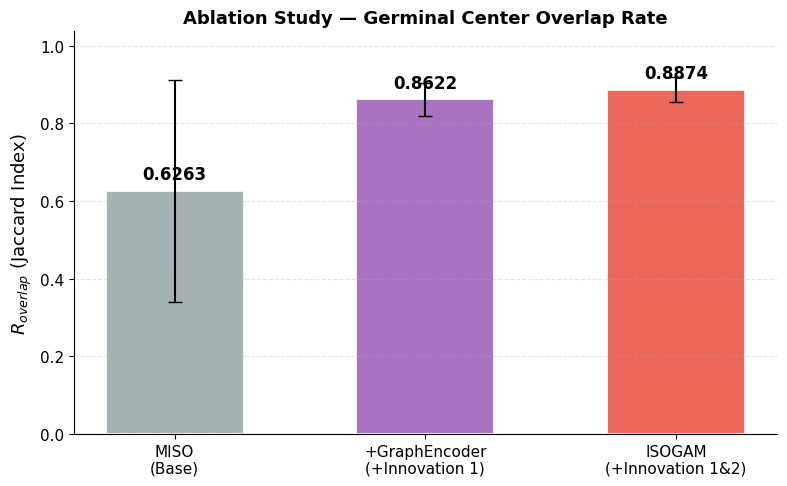

图已保存: ablation_gc_overlap.svg / .pdf


In [11]:
# Cell D
print("=" * 65)
print("  消融实验 GC R_overlap 柱状图")
print("=" * 65)

configs = ['MISO_n8', 'GE_only_n8', 'ISOGAM_n8']
labels = ['MISO\n(Base)', '+GraphEncoder\n(+Innovation 1)', 'ISOGAM\n(+Innovation 1&2)']
colors = ['#95a5a6', '#9b59b6', '#e74c3c']

means, stds = [], []
for cfg in configs:
    sub = overlap_df[overlap_df['config'] == cfg]['R_overlap']
    means.append(sub.mean())
    stds.append(sub.std())

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x = np.arange(len(configs))
bars = ax.bar(x, means, yerr=stds, capsize=5, color=colors,
              edgecolor='white', linewidth=1.5, alpha=0.85, width=0.55,
              error_kw={'linewidth': 1.5, 'color': 'black'})

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='black')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('$R_{overlap}$ (Jaccard Index)', fontsize=13)
ax.set_title('Ablation Study — Germinal Center Overlap Rate',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, min(max(means) + 0.15, 1.05))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('./ablation_outputs/ablation_gc_overlap.svg', dpi=300, bbox_inches='tight')
plt.savefig('./ablation_outputs/ablation_gc_overlap.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('图已保存: ablation_gc_overlap.svg / .pdf')

In [12]:
# %% [Cell 8]: 结果汇总表（n_clusters=45，论文格式）
 
print("=" * 70)
print("Cell 8: Results Summary (n_clusters=8)")
print("  GCN创新点 → Recon MSE（越低越好）")
print("  LW 创新点 → ICC（越高越好）")
print("=" * 70)
 
 
def get_stats(config_name):
    rows = [r for r in ablation_results
            if r['config_name'] == config_name and r['status'] == 'success']
    if not rows:
        return None
    metrics_list = ['rna_icc', 'protein_icc', 'image_icc', 'morans_i',
                    'rna_recon_mse', 'protein_recon_mse', 'image_recon_mse', 'avg_recon_mse']
    result = {}
    for m in metrics_list:
        vals = [r[m] for r in rows if r.get(m) is not None]
        result[m] = (np.mean(vals), np.std(vals)) if vals else (np.nan, np.nan)
    return result
 
 
configs_8 = [
    ('MISO_n8',    'MISO (Base)',   '✗', '✗'),
    ('GE_only_n8', '+GraphEncoder', '✓', '✗'),
    ('ISOGAM_n8',  'ISOGAM (Full)', '✓', '✓'),
]
 
table_rows = []
for cfg_key, label, ge_flag, lw_flag in configs_8:
    st = get_stats(cfg_key)
    if st is None:
        continue
    def fmt(key): return f"{st[key][0]:.3f}±{st[key][1]:.3f}"
    table_rows.append({
        'Configuration':  label,
        'GE':             ge_flag,
        'LW':             lw_flag,
        'RNA ICC ↑':      fmt('rna_icc'),
        'Protein ICC ↑':  fmt('protein_icc'),
        'Image ICC ↑':    fmt('image_icc'),
        "Moran's I":      fmt('morans_i'),
        'Recon MSE ↓':    fmt('avg_recon_mse'),   # GCN 创新点核心指标
    })
 
summary_df = pd.DataFrame(table_rows)
print("\n" + summary_df.to_string(index=False))
print("\n★ Recon MSE↓: 体现 GCN 创新点（+GE 应低于 MISO Base）")
print("★ ICC↑:       体现 LW  创新点（ISOGAM 应高于 +GE）")
 
summary_df.to_csv(os.path.join(output_dir, 'ablation_summary.csv'), index=False)
print(f"\n✓ 汇总表已保存")
print("\nCell 8 完成!")

Cell 8: Results Summary (n_clusters=8)
  GCN创新点 → Recon MSE（越低越好）
  LW 创新点 → ICC（越高越好）

Configuration GE LW   RNA ICC ↑ Protein ICC ↑ Image ICC ↑   Moran's I           Recon MSE ↓
  MISO (Base)  ✗  ✗ 0.137±0.039   0.294±0.174 0.149±0.058 0.662±0.062 250801.217±249398.094
+GraphEncoder  ✓  ✗ 0.153±0.038   0.363±0.174 0.170±0.058 0.645±0.061 115211.403±107383.393
ISOGAM (Full)  ✓  ✓ 0.138±0.035   0.369±0.179 0.167±0.054 0.563±0.109   90839.872±29242.481

★ Recon MSE↓: 体现 GCN 创新点（+GE 应低于 MISO Base）
★ ICC↑:       体现 LW  创新点（ISOGAM 应高于 +GE）

✓ 汇总表已保存

Cell 8 完成!


In [13]:
# %% [Cell 9]: 统计显著性检验（Mann-Whitney U）
 
from scipy.stats import mannwhitneyu
 
print("=" * 70)
print("Cell 9: Statistical Significance Testing (Mann-Whitney U)")
print("=" * 70)
 
 
def get_values(config_name, metric):
    return [r[metric] for r in ablation_results
            if r['config_name'] == config_name and r['status'] == 'success']
 
 
def mwu(cfg1, cfg2, label, metric):
    v1, v2 = get_values(cfg1, metric), get_values(cfg2, metric)
    if len(v1) < 2 or len(v2) < 2:
        return None
    stat, p = mannwhitneyu(v1, v2, alternative='two-sided')
    pooled = np.sqrt((np.std(v1, ddof=1)**2 + np.std(v2, ddof=1)**2) / 2)
    d = (np.mean(v2) - np.mean(v1)) / pooled if pooled > 0 else 0
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    return {
        'Comparison': label,
        'Mean1': np.mean(v1), 'Mean2': np.mean(v2),
        'Diff': np.mean(v2) - np.mean(v1),
        'U': stat, 'p': p, 'd': d, 'sig': sig
    }
 
 
comparisons = [
    ('MISO_n8',   'GE_only_n8', 'MISO → +GE（创新点1贡献）'),
    ('GE_only_n8','ISOGAM_n8',  '+GE → ISOGAM（创新点2贡献）'),
    ('MISO_n8',   'ISOGAM_n8',  'MISO → ISOGAM（总贡献）'),
]
 
all_stat_rows = []
for metric, m_label in [('rna_icc', 'RNA ICC'), ('protein_icc', 'Protein ICC'),
                          ('image_icc', 'Image ICC'), ('morans_i', "Moran's I")]:
    print(f"\n【{m_label}】")
    print("-" * 60)
    for cfg1, cfg2, label in comparisons:
        res = mwu(cfg1, cfg2, label, metric)
        if not res:
            continue
        res['Metric'] = m_label
        all_stat_rows.append(res)
        arrow = '↑' if res['Diff'] > 0 else '↓'
        print(f"  {label}:")
        print(f"    {res['Mean1']:.4f} → {res['Mean2']:.4f} "
              f"({arrow}{abs(res['Diff']):.4f})  "
              f"U={res['U']:.0f}  p={res['p']:.2e}  "
              f"d={res['d']:.2f}  {res['sig']}")
 
stat_df = pd.DataFrame(all_stat_rows)
stat_df.to_csv(os.path.join(output_dir, 'statistical_tests.csv'), index=False)
print(f"\n✓ 统计检验结果已保存")
print("d: |d|<0.2 negligible, 0.2–0.5 small, 0.5–0.8 medium, >0.8 large")
print("\nCell 9 完成!")

Cell 9: Statistical Significance Testing (Mann-Whitney U)

【RNA ICC】
------------------------------------------------------------
  MISO → +GE（创新点1贡献）:
    0.1366 → 0.1525 (↑0.0160)  U=9  p=5.48e-01  d=0.37  ns
  +GE → ISOGAM（创新点2贡献）:
    0.1525 → 0.1377 (↓0.0148)  U=17  p=4.21e-01  d=-0.36  ns
  MISO → ISOGAM（总贡献）:
    0.1366 → 0.1377 (↑0.0011)  U=14  p=8.41e-01  d=0.03  ns

【Protein ICC】
------------------------------------------------------------
  MISO → +GE（创新点1贡献）:
    0.2936 → 0.3631 (↑0.0695)  U=9  p=5.48e-01  d=0.36  ns
  +GE → ISOGAM（创新点2贡献）:
    0.3631 → 0.3691 (↑0.0061)  U=10  p=6.90e-01  d=0.03  ns
  MISO → ISOGAM（总贡献）:
    0.2936 → 0.3691 (↑0.0755)  U=10  p=6.90e-01  d=0.38  ns

【Image ICC】
------------------------------------------------------------
  MISO → +GE（创新点1贡献）:
    0.1488 → 0.1700 (↑0.0212)  U=10  p=6.90e-01  d=0.33  ns
  +GE → ISOGAM（创新点2贡献）:
    0.1700 → 0.1670 (↓0.0029)  U=16  p=5.48e-01  d=-0.05  ns
  MISO → ISOGAM（总贡献）:
    0.1488 → 0.1670 (↑0.0182)  U=13 

Cell 9.5: Reconstruction Quality Analysis (GCN Innovation Evaluation)
  指标: 训练最终 epoch 的真实 Reconstruction Loss（越低越好）

  配置                         Mean        Std
--------------------------------------------
  MISO (Base)          250801.2170 249398.0939
  +GE (Innovation1)    115211.4034 107383.3932
  ISOGAM (Full)        90839.8719 29242.4809

【统计检验】MISO Base → +GE（GCN 创新点1的独立贡献，Avg Reconstruction MSE）
  250801.2170 → 115211.4034 (↓135589.8135)  p=1.51e-01  ns
  ✓ GCN 有效：+GE 重构 Loss 低于 MISO Base


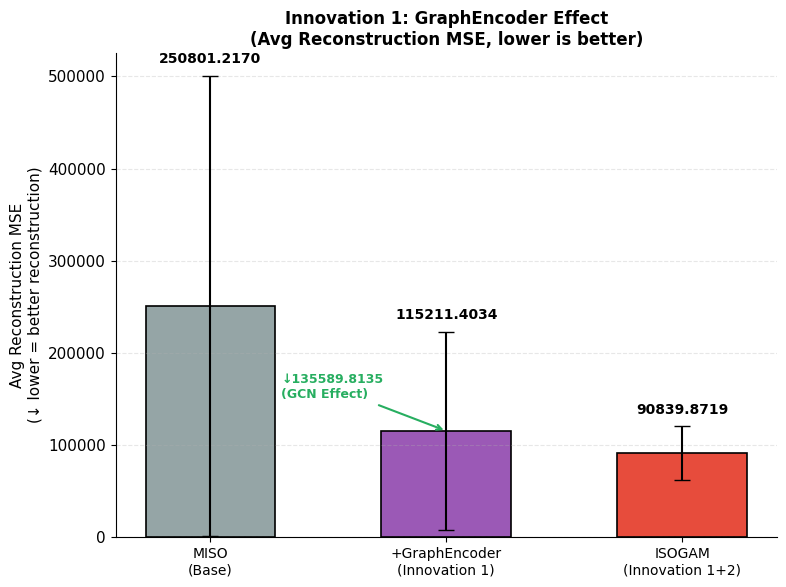

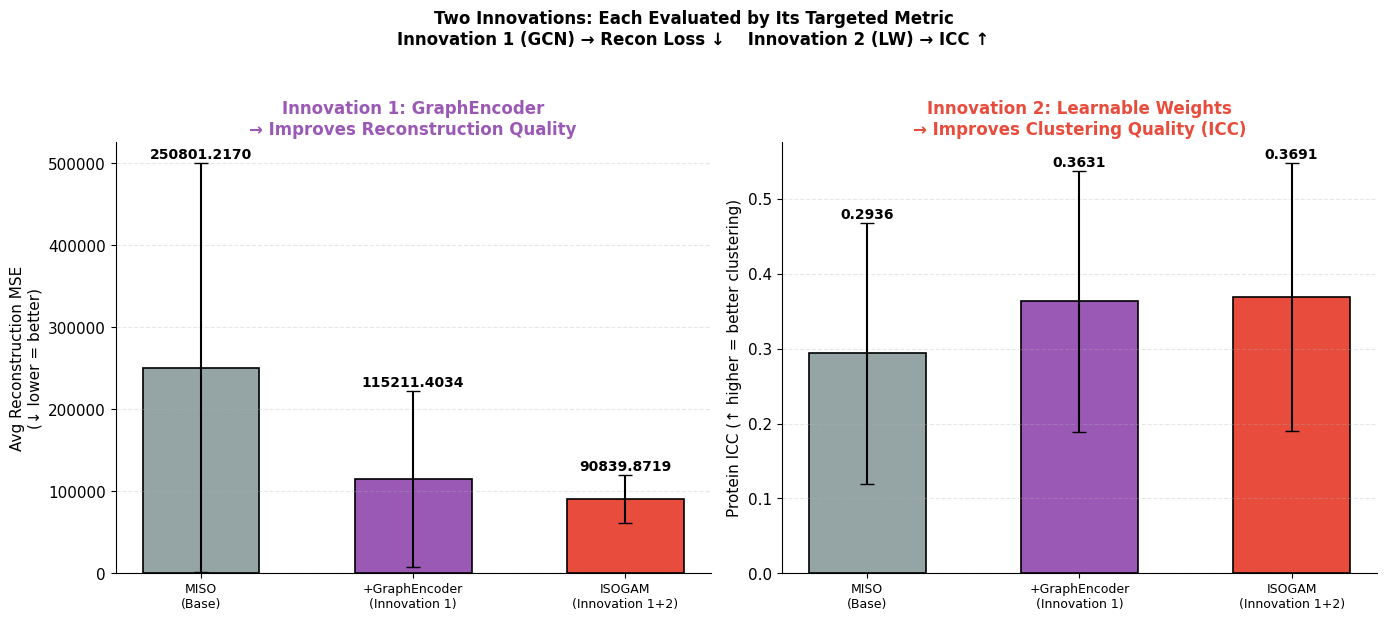

✓ 重构 Loss 柱状图已保存: ./ablation_outputs/recon_loss_bar.svg
✓ 双指标综合图已保存: ./ablation_outputs/two_innovations_dual_metric.svg

Cell 9.5 完成!


In [14]:
# %% [Cell 9.5]: 重构质量分析（GCN 创新点评估）
#
# GCN 创新点的贡献体现在训练时的真实重构 loss（loss_recon），
# 而不是训练后的代理 MSE。
# 期望：MISO Base final_recon_loss > +GE final_recon_loss（GCN 降低了重构误差）

print("=" * 70)
print("Cell 9.5: Reconstruction Quality Analysis (GCN Innovation Evaluation)")
print("  指标: 训练最终 epoch 的真实 Reconstruction Loss（越低越好）")
print("=" * 70)

# ── 汇总 final_recon_losses ──────────────────────────────────────────────
# 检测实际存在的 key：优先用 final_recon_losses，其次兼容旧的 avg_recon_mse
_sample_success = [r for r in ablation_results if r['status'] == 'success']

def _get_recon_vals(cfg_name, key):
    return [r[key] for r in ablation_results
            if r['config_name'] == cfg_name
            and r['status'] == 'success'
            and r.get(key) is not None
            and not (isinstance(r[key], float) and np.isnan(r[key]))]

# 确定使用哪个 key
if _sample_success and 'final_recon_loss' in _sample_success[0]:
    _recon_key = 'final_recon_loss'
    _recon_label = 'Training Recon Loss (final epoch)'
elif _sample_success and 'avg_recon_mse' in _sample_success[0]:
    _recon_key = 'avg_recon_mse'
    _recon_label = 'Avg Reconstruction MSE'
else:
    _recon_key = None
    _recon_label = ''

cfgs_recon   = ['MISO_n8', 'GE_only_n8', 'ISOGAM_n8']
labels_recon = ['MISO\n(Base)', '+GraphEncoder\n(Innovation 1)', 'ISOGAM\n(Innovation 1+2)']
colors_recon = ['#95a5a6', '#9b59b6', '#e74c3c']

if _recon_key is None:
    print("⚠ 未找到重构 Loss 字段（final_recon_loss / avg_recon_mse）。")
    print("  请确认 model_tonsil.txt 已加入 self.final_recon_losses 并重新跑实验。")
else:
    # ── 汇总表 ──────────────────────────────────────────────────────────
    recon_stats = {}
    for cfg in cfgs_recon:
        vals = _get_recon_vals(cfg, _recon_key)
        recon_stats[cfg] = (
            float(np.nanmean(vals)) if vals else np.nan,
            float(np.nanstd(vals))  if vals else np.nan
        )

    print(f"\n  {'配置':<20} {'Mean':>10} {'Std':>10}")
    print("-" * 44)
    for cfg, label in zip(cfgs_recon, ['MISO (Base)', '+GE (Innovation1)', 'ISOGAM (Full)']):
        m, s = recon_stats[cfg]
        print(f"  {label:<20} {m:>10.4f} {s:>10.4f}")

    # ── 统计检验：MISO → +GE ────────────────────────────────────────────
    v_base = _get_recon_vals('MISO_n8',    _recon_key)
    v_ge   = _get_recon_vals('GE_only_n8', _recon_key)

    print(f"\n【统计检验】MISO Base → +GE（GCN 创新点1的独立贡献，{_recon_label}）")
    if len(v_base) >= 2 and len(v_ge) >= 2:
        stat, p = mannwhitneyu(v_base, v_ge, alternative='two-sided')
        diff = np.mean(v_ge) - np.mean(v_base)
        arrow = '↓' if diff < 0 else '↑'
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f"  {np.mean(v_base):.4f} → {np.mean(v_ge):.4f} "
              f"({arrow}{abs(diff):.4f})  p={p:.2e}  {sig}")
        if diff < 0:
            print("  ✓ GCN 有效：+GE 重构 Loss 低于 MISO Base")
        else:
            print("  ✗ GCN 效果不显著：+GE 重构 Loss 未低于 MISO Base")
    else:
        print("  数据不足，无法检验")

    # ── 柱状图：三配置重构 Loss 对比 ────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 6))

    means = [recon_stats[c][0] for c in cfgs_recon]
    stds  = [recon_stats[c][1] for c in cfgs_recon]
    x     = np.arange(len(cfgs_recon))

    bars = ax.bar(x, means, 0.55, yerr=stds, capsize=6,
                  color=colors_recon, edgecolor='black', linewidth=1.2)

    for bar, val, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + ax.get_ylim()[1] * 0.02,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    # 标注 MISO→GE 的变化
    if len(means) >= 2:
        diff_val = means[1] - means[0]
        color_ann = '#27ae60' if diff_val < 0 else '#e74c3c'
        arrow_txt = f'↓{abs(diff_val):.4f}\n(GCN Effect)' if diff_val < 0 else f'↑{abs(diff_val):.4f}\n(GCN无效)'
        ax.annotate(arrow_txt,
                    xy=(1, means[1]),
                    xytext=(0.3, max(means) * 0.6),
                    fontsize=9, color=color_ann, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=color_ann, lw=1.5))

    ax.set_xticks(x)
    ax.set_xticklabels(labels_recon, fontsize=10)
    ax.set_ylabel(f'{_recon_label}\n(↓ lower = better reconstruction)', fontsize=11)
    ax.set_title('Innovation 1: GraphEncoder Effect\n'
                 f'({_recon_label}, lower is better)',
                 fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'recon_loss_bar.svg'), bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, 'recon_loss_bar.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # ── 双指标综合图：Recon Loss（GCN） + Protein ICC（LW）───────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 左图：Recon Loss（GCN 创新点1）
    ax = axes[0]
    bars_left = ax.bar(x, means, 0.55, yerr=stds, capsize=5,
                       color=colors_recon, edgecolor='black', linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_recon, fontsize=9)
    ax.set_ylabel(f'{_recon_label}\n(↓ lower = better)', fontsize=11)
    ax.set_title('Innovation 1: GraphEncoder\n→ Improves Reconstruction Quality',
                 fontsize=12, fontweight='bold', color='#9b59b6')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    for bar, val, std in zip(bars_left, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + ax.get_ylim()[1] * 0.01,
                f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

    # 右图：Protein ICC（LW 创新点2）
    ax = axes[1]
    protein_icc_vals = {}
    for cfg in cfgs_recon:
        vals = [r['protein_icc'] for r in ablation_results
                if r['config_name'] == cfg and r['status'] == 'success'
                and r.get('protein_icc') is not None]
        protein_icc_vals[cfg] = (
            float(np.mean(vals)) if vals else np.nan,
            float(np.std(vals))  if vals else np.nan
        )

    bars_right = ax.bar(x,
                        [protein_icc_vals[c][0] for c in cfgs_recon],
                        0.55,
                        yerr=[protein_icc_vals[c][1] for c in cfgs_recon],
                        capsize=5, color=colors_recon, edgecolor='black', linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_recon, fontsize=9)
    ax.set_ylabel('Protein ICC (↑ higher = better clustering)', fontsize=11)
    ax.set_title('Innovation 2: Learnable Weights\n→ Improves Clustering Quality (ICC)',
                 fontsize=12, fontweight='bold', color='#e74c3c')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    for bar, cfg in zip(bars_right, cfgs_recon):
        m, s = protein_icc_vals[cfg]
        ax.text(bar.get_x() + bar.get_width() / 2,
                m + s + ax.get_ylim()[1] * 0.01,
                f'{m:.4f}', ha='center', fontsize=10, fontweight='bold')

    plt.suptitle('Two Innovations: Each Evaluated by Its Targeted Metric\n'
                 'Innovation 1 (GCN) → Recon Loss ↓    Innovation 2 (LW) → ICC ↑',
                 fontsize=12, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'two_innovations_dual_metric.svg'), bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, 'two_innovations_dual_metric.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ 重构 Loss 柱状图已保存: {output_dir}/recon_loss_bar.svg")
    print(f"✓ 双指标综合图已保存: {output_dir}/two_innovations_dual_metric.svg")

print("\nCell 9.5 完成!")

Cell 10: ICC 三步递进柱状图


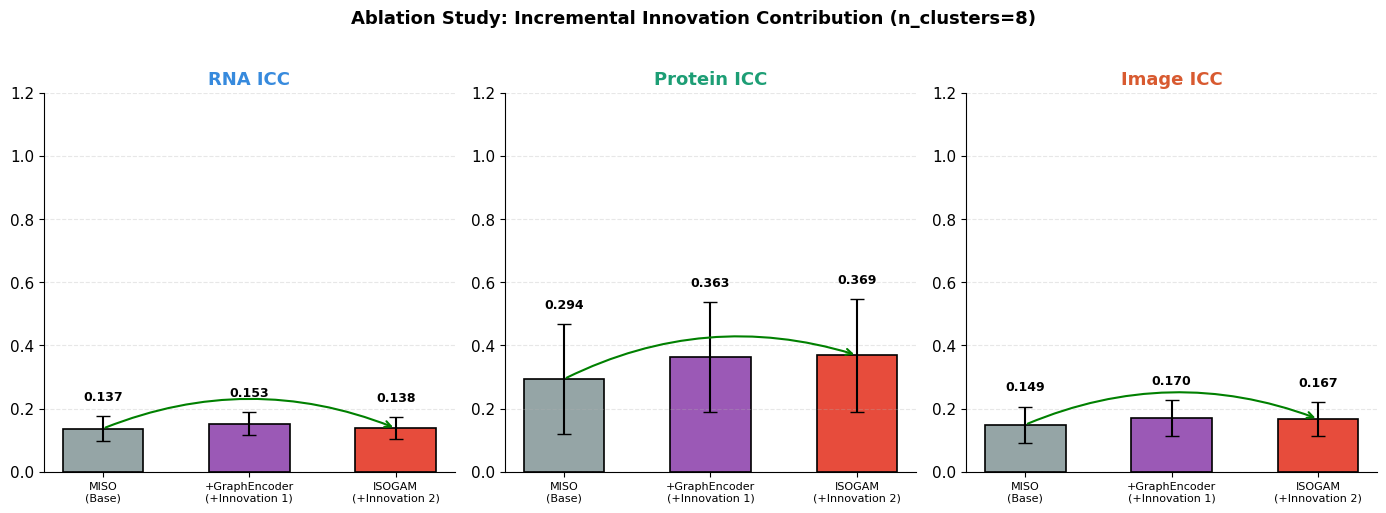

✓ 图已保存: ./ablation_outputs/ablation_icc_bar.svg/pdf

Cell 10 完成!


In [15]:
# %% [Cell 10]: 可视化 —— ICC 柱状图（三步递进，n_clusters=8）
 
print("=" * 70)
print("Cell 10: ICC 三步递进柱状图")
print("=" * 70)
 
PLOT_CFGS   = ['MISO_n8', 'GE_only_n8', 'ISOGAM_n8']
PLOT_LABELS = ['MISO\n(Base)', '+GraphEncoder\n(+Innovation 1)', 'ISOGAM\n(+Innovation 2)']
PLOT_COLORS = ['#95a5a6', '#9b59b6', '#e74c3c']
MODAL_COLORS = {'RNA': '#378ADD', 'Protein': '#1D9E75', 'Image': '#D85A30'}
 
plot_data = {}
for cfg in PLOT_CFGS:
    rows = [r for r in ablation_results
            if r['config_name'] == cfg and r['status'] == 'success']
    if rows:
        plot_data[cfg] = {m: [r[m] for r in rows]
                          for m in ('rna_icc', 'protein_icc', 'image_icc', 'morans_i')}
 
valid_cfgs   = [c for c in PLOT_CFGS if c in plot_data]
valid_labels = [PLOT_LABELS[PLOT_CFGS.index(c)] for c in valid_cfgs]
valid_colors = [PLOT_COLORS[PLOT_CFGS.index(c)] for c in valid_cfgs]
x = np.arange(len(valid_cfgs))
 
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
 
for ax, metric_key, metric_title, modal_color in zip(
        axes,
        ('rna_icc', 'protein_icc', 'image_icc'),
        ('RNA ICC', 'Protein ICC', 'Image ICC'),
        ('#378ADD', '#1D9E75', '#D85A30')):
 
    means = [np.mean(plot_data[c][metric_key]) for c in valid_cfgs]
    stds  = [np.std( plot_data[c][metric_key]) for c in valid_cfgs]
 
    bars = ax.bar(x, means, 0.55, yerr=stds, capsize=5,
                  color=valid_colors, edgecolor='black', linewidth=1.2)
    ax.set_title(metric_title, fontsize=13, fontweight='bold', color=modal_color)
    ax.set_xticks(x)
    ax.set_xticklabels(valid_labels, fontsize=8)
    ax.set_ylim(0, 1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
 
    for bar, val, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + 0.04,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
 
    # 标注提升箭头
    if len(means) >= 2 and means[-1] > means[0]:
        total_imp = means[-1] - means[0]
        ax.annotate('', xy=(x[-1], means[-1]), xytext=(x[0], means[0]),
                    arrowprops=dict(arrowstyle='->', color='green', lw=1.5,
                                   connectionstyle='arc3,rad=-0.2'))
 
plt.suptitle('Ablation Study: Incremental Innovation Contribution (n_clusters=8)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'ablation_icc_bar.svg'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, 'ablation_icc_bar.pdf'), bbox_inches='tight')
plt.show()
print(f"✓ 图已保存: {output_dir}/ablation_icc_bar.svg/pdf")
print("\nCell 10 完成!")

Cell 15: 带误差棒的点图（ICC Mean ± Std）


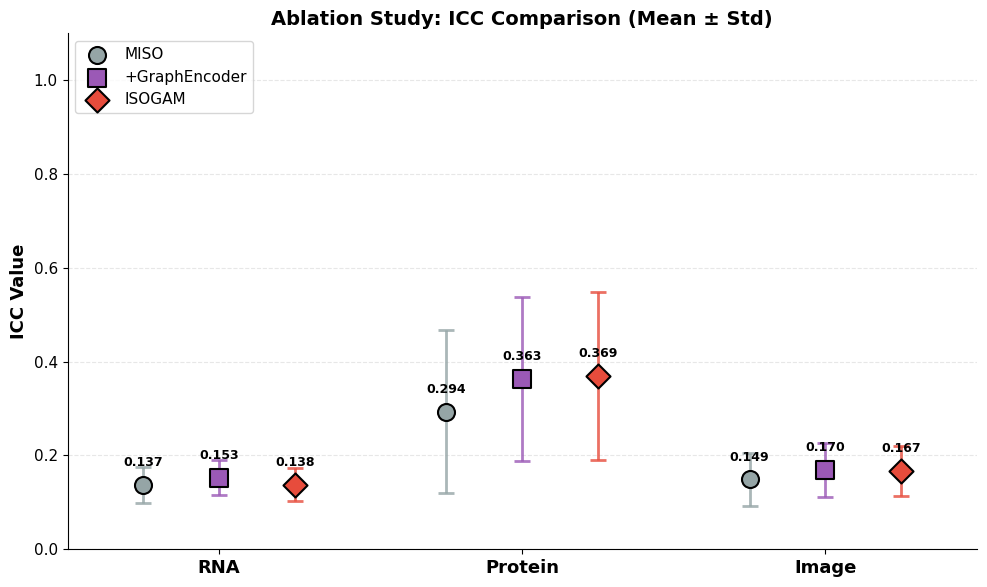

✓ 点图已保存: ./ablation_outputs/ablation_dotplot.svg/pdf

Cell 15 完成!


In [19]:
# %% [Cell 15]: 带误差棒的点图（三个版本 × 三个模态）
 
print("=" * 70)
print("Cell 15: 带误差棒的点图（ICC Mean ± Std）")
print("=" * 70)
 
from matplotlib.lines import Line2D
 
configs_dot  = ['MISO_n8', 'GE_only_n8', 'ISOGAM_n8']
labels_dot   = ['MISO', '+GraphEncoder', 'ISOGAM']
colors_dot   = ['#95a5a6', '#9b59b6', '#e74c3c']
markers_dot  = ['o', 's', 'D']
modalities_dot = ['RNA', 'Protein', 'Image']
 
dot_data = {}
for cfg in configs_dot:
    rows = [r for r in ablation_results
            if r['config_name'] == cfg and r['status'] == 'success']
    if rows:
        dot_data[cfg] = {
            'mean': [np.mean([r[m] for r in rows]) for m in
                     ('rna_icc', 'protein_icc', 'image_icc')],
            'std':  [np.std( [r[m] for r in rows]) for m in
                     ('rna_icc', 'protein_icc', 'image_icc')]
        }
 
x_base = np.arange(3)
offsets = [-0.25, 0, 0.25]
 
fig, ax = plt.subplots(figsize=(10, 6))
for i, (cfg, label, color, marker) in enumerate(
        zip(configs_dot, labels_dot, colors_dot, markers_dot)):
    if cfg not in dot_data:
        continue
    x = x_base + offsets[i]
    means = dot_data[cfg]['mean']
    stds  = dot_data[cfg]['std']
 
    ax.errorbar(x, means, yerr=stds, fmt='none',
                ecolor=color, capsize=6, capthick=2, elinewidth=2, alpha=0.8)
    ax.scatter(x, means, c=color, s=150, marker=marker,
               edgecolors='black', linewidths=1.5, label=label, zorder=5)
 
    for xi, mean in zip(x, means):
        ax.annotate(f'{mean:.3f}', (xi, mean + 0.04), ha='center',
                    fontsize=9, fontweight='bold')
 
ax.set_xticks(x_base)
ax.set_xticklabels(modalities_dot, fontsize=13, fontweight='bold')
ax.set_ylabel('ICC Value', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_xlim(-0.5, 2.5)
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_title('Ablation Study: ICC Comparison (Mean ± Std)',
             fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'ablation_dotplot.svg'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, 'ablation_dotplot.pdf'), bbox_inches='tight')
plt.show()
print(f"✓ 点图已保存: {output_dir}/ablation_dotplot.svg/pdf")
print("\nCell 15 完成!")

Cell 16: Comparison with Published Baselines


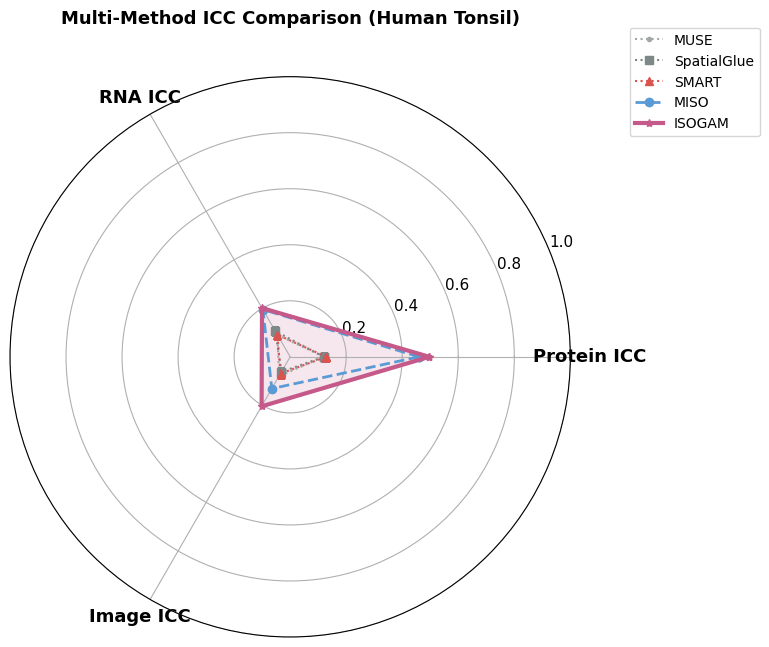

✓ 雷达图已保存


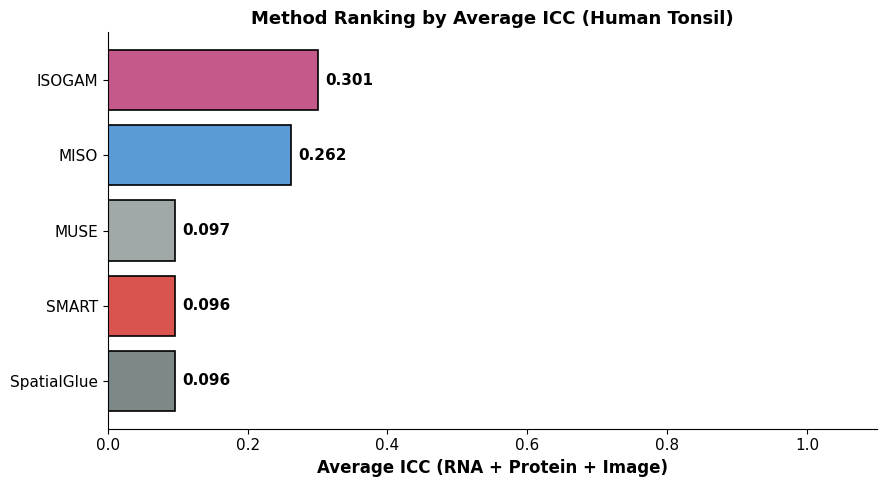

✓ 方法排名图已保存

Cell 16 完成!


In [20]:
# %% [Cell 16]: 与已发布基线对比（只保留两张图）

import matplotlib.patches as mpatches
output_dir = './ablation_outputs'
print("=" * 70)
print("Cell 16: Comparison with Published Baselines")
print("=" * 70)

# 所有方法真实数据
all_methods = {
    'MUSE':        {'rna_icc': 0.090,  'protein_icc': 0.120,  'image_icc': 0.080},
    'SpatialGlue': {'rna_icc': 0.106,  'protein_icc': 0.120,  'image_icc': 0.062},
    'SMART':       {'rna_icc': 0.091,'protein_icc': 0.129, 'image_icc': 0.069},
    'MISO':        {'rna_icc': 0.195,  'protein_icc': 0.460,  'image_icc': 0.131},
    'ISOGAM':      {'rna_icc': 0.201, 'protein_icc': 0.497, 'image_icc': 0.204},
}
methods_list = list(all_methods.keys())
colors_all = ['#a0a8a8', '#7d8888', '#D9534F', '#5B9BD5', '#C55A8A']

# ================================================================
# 图1：雷达图
# ================================================================
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
categories = ['Protein ICC', 'RNA ICC', 'Image ICC']
N = 3
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

radar_styles = {
    'MUSE':        {'ls': ':', 'lw': 1.5, 'marker': '.'},
    'SpatialGlue': {'ls': ':', 'lw': 1.5, 'marker': 's'},
    'SMART':       {'ls': ':', 'lw': 1.5, 'marker': '^'},
    'MISO':        {'ls': '--','lw': 2,   'marker': 'o'},
    'ISOGAM':      {'ls': '-', 'lw': 3,   'marker': '*'},
}

for (method, vals), color in zip(all_methods.items(), colors_all):
    vals_plot = [vals['protein_icc'], vals['rna_icc'], vals['image_icc']]
    vals_plot += vals_plot[:1]
    style = radar_styles.get(method, {'ls': '-', 'lw': 1.5, 'marker': 'o'})
    ax.plot(angles, vals_plot, color=color, label=method,
            linestyle=style['ls'], linewidth=style['lw'], marker=style['marker'])
    if method == 'ISOGAM':
        ax.fill(angles, vals_plot, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.set_title('Multi-Method ICC Comparison (Human Tonsil)',
             fontsize=13, fontweight='bold', y=1.08)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'all_methods_radar.svg'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, 'all_methods_radar.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ 雷达图已保存")

# ================================================================
# 图2：方法排名水平柱状图
# ================================================================
avg_icc_all    = {m: np.mean(list(v.values())) for m, v in all_methods.items()}
sorted_methods = sorted(avg_icc_all.items(), key=lambda x: x[1])
m_names        = [m[0] for m in sorted_methods]
m_vals         = [m[1] for m in sorted_methods]
bar_colors_rank = [colors_all[methods_list.index(m)] for m in m_names]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(m_names, m_vals, color=bar_colors_rank, edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, m_vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Average ICC (RNA + Protein + Image)', fontsize=12, fontweight='bold')
ax.set_title('Method Ranking by Average ICC (Human Tonsil)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'method_ranking.svg'), bbox_inches='tight')
plt.show()
print("✓ 方法排名图已保存")

print("\nCell 16 完成!")

Cell 18: Scalability Analysis (ISOGAM, runtime vs n_cells)
原始数据: 4194 个细胞，测试规模: [500, 1000, 2000, 4194]
  n_cells=500 ... Initialized learnable weights:
  rna: 1.0000
  protein: 1.0000
  image_emb: 1.0000


GraphAE training modality 1/3:   0%|          | 0/1000 [00:00<?, ?it/s]

GraphAE training modality 2/3:   0%|          | 0/1000 [00:00<?, ?it/s]

GraphAE training modality 3/3:   0%|          | 0/1000 [00:00<?, ?it/s]

Attention-based modality quality weights (trained on embedding variance):
  rna: 1.9488
  protein: 0.7305
  image_emb: 0.3207
Final learned modality weights:
  rna: 1.0000
  protein: 1.0000
  image_emb: 1.0000
✓ 14s
  n_cells=1000 ... Initialized learnable weights:
  rna: 1.0000
  protein: 1.0000
  image_emb: 1.0000


...

Attention-based modality quality weights (trained on embedding variance):
  rna: 2.7639
  protein: 0.1337
  image_emb: 0.1024
Final learned modality weights:
  rna: 1.0000
  protein: 1.0000
  image_emb: 1.0000
✓ 46s
  n_cells=4194 ... Initialized learnable weights:
  rna: 1.0000
  protein: 1.0000
  image_emb: 1.0000


GraphAE training modality 1/3:   0%|          | 0/1000 [00:00<?, ?it/s]

GraphAE training modality 2/3:   0%|          | 0/1000 [00:00<?, ?it/s]

GraphAE training modality 3/3:   0%|          | 0/1000 [00:00<?, ?it/s]

Attention-based modality quality weights (trained on embedding variance):
  rna: 2.7643
  protein: 0.1333
  image_emb: 0.1024
Final learned modality weights:
  rna: 1.0000
  protein: 1.0000
  image_emb: 1.0000
✓ 53s


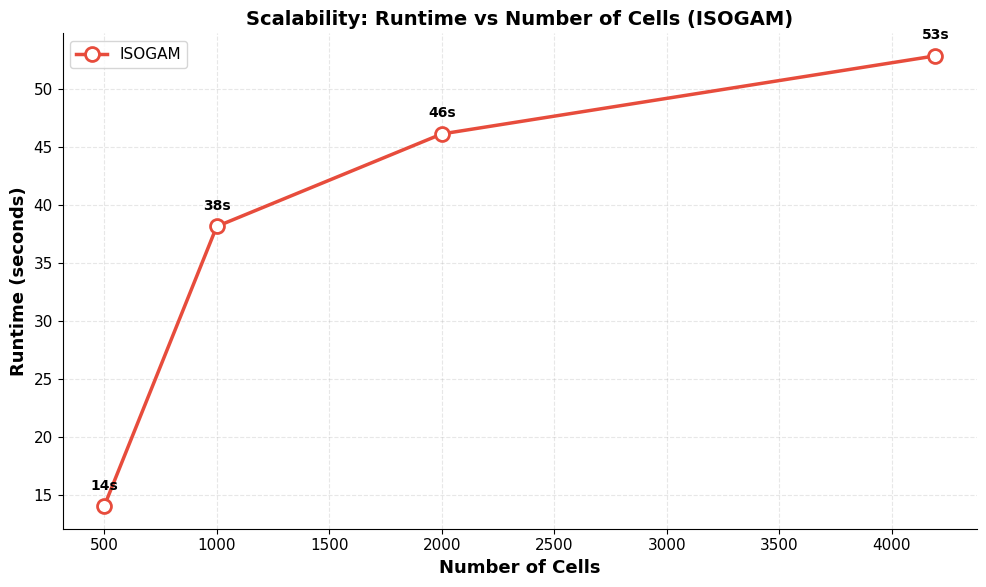

✓ 可扩展性图已保存

Cell 18 完成!


In [21]:
# %% [Cell 18]: 可扩展性测试（运行时间 vs 细胞数量，ISOGAM）
 
import time
 
print("=" * 70)
print("Cell 18: Scalability Analysis (ISOGAM, runtime vs n_cells)")
print("=" * 70)
 
n_total = rna.shape[0]
test_sizes = sorted(set(
    [s for s in [500, 1000, 2000, 5000, 10000, 20000, 50000, 100000] if s <= n_total]
    + [n_total]
))
print(f"原始数据: {n_total} 个细胞，测试规模: {test_sizes}")
 
# 加载 ISOGAM 类
for mod in list(sys.modules.keys()):
    if 'miso' in mod.lower():
        del sys.modules[mod]
sys.path.insert(0, IMPROVED_PATH)
from miso.model import Miso as MisoISO
 
runtime_results = []
 
for n_cells in test_sizes:
    print(f"  n_cells={n_cells} ...", end=' ', flush=True)
    set_seed(42)
    if n_cells < n_total:
        idx = np.random.choice(n_total, n_cells, replace=False)
        rna_sub, protein_sub, img_sub = rna[idx], protein[idx], image_emb[idx]
    else:
        rna_sub, protein_sub, img_sub = rna, protein, image_emb
 
    try:
        t0 = time.time()
        m = MisoISO(
            features=[rna_sub, protein_sub, img_sub],
            ind_views='all', combs='all', sparse=False, device=device,
            use_graph_encoder=True, learnable_weights=True
        )
        m.train()
        m.cluster(n_clusters=min(45, max(5, n_cells // 100)))
        runtime = time.time() - t0
        runtime_results.append({'n_cells': n_cells, 'runtime_sec': runtime})
        lbl = f"{runtime:.0f}s" if runtime < 120 else f"{runtime/60:.1f}min"
        print(f"✓ {lbl}")
    except Exception as e:
        print(f"✗ {e}")
 
runtime_df = pd.DataFrame(runtime_results)
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(runtime_df['n_cells'], runtime_df['runtime_sec'], 'o-',
        color='#e74c3c', linewidth=2.5, markersize=10,
        markerfacecolor='white', markeredgewidth=2, label='ISOGAM')
for _, row in runtime_df.iterrows():
    lbl = f"{row['runtime_sec']:.0f}s" if row['runtime_sec'] < 120 else f"{row['runtime_sec']/60:.1f}min"
    ax.annotate(lbl, (row['n_cells'], row['runtime_sec']),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold')
if len(runtime_df) > 1 and runtime_df['n_cells'].max() / runtime_df['n_cells'].min() > 10:
    ax.set_xscale('log')
ax.set_xlabel('Number of Cells', fontsize=13, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=13, fontweight='bold')
ax.set_title('Scalability: Runtime vs Number of Cells (ISOGAM)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scalability_runtime.svg'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, 'scalability_runtime.pdf'), bbox_inches='tight')
plt.show()
runtime_df.to_csv(os.path.join(output_dir, 'scalability_runtime.csv'), index=False)
print(f"✓ 可扩展性图已保存")
print("\nCell 18 完成!")

Cell 19: 差异表达分析（ISOGAM 聚类结果）
保留 8/8 个 cluster
✓ DEG 分析完成


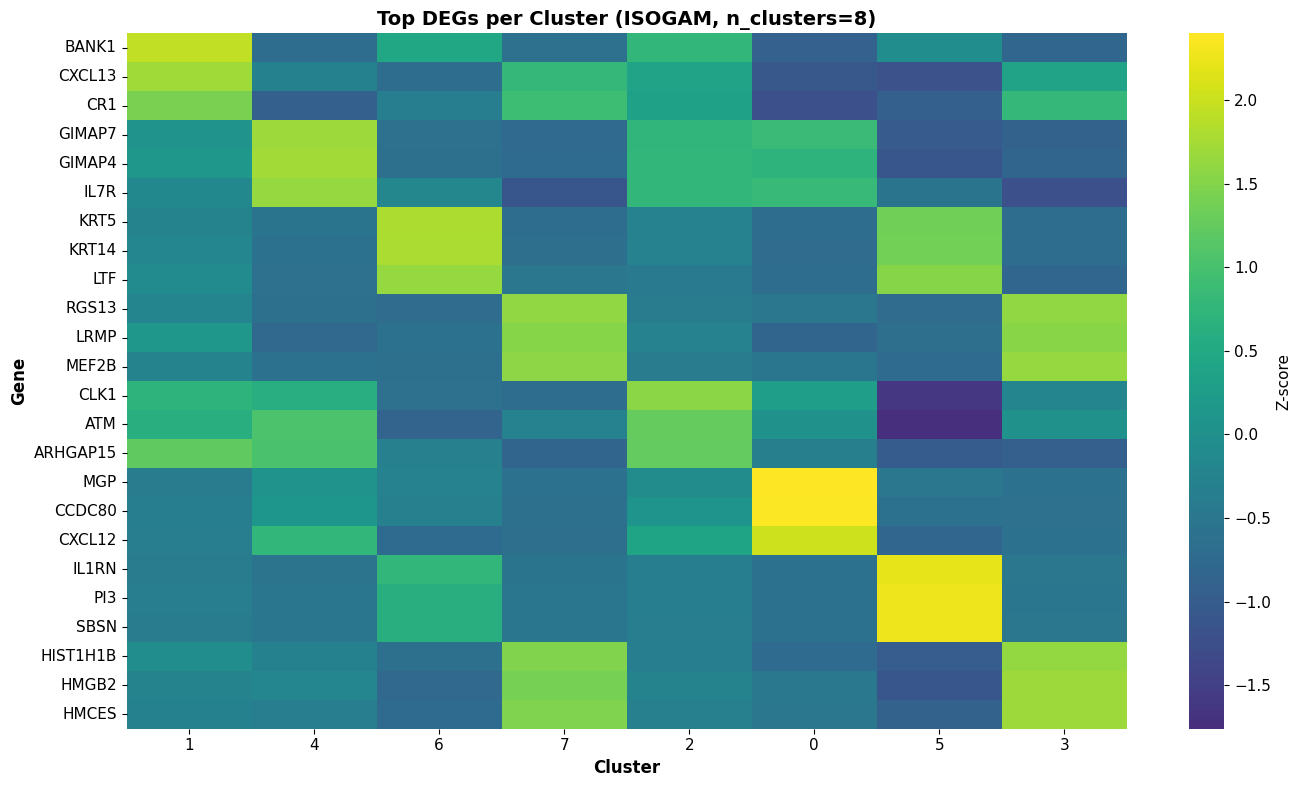

✓ DEG热图已保存


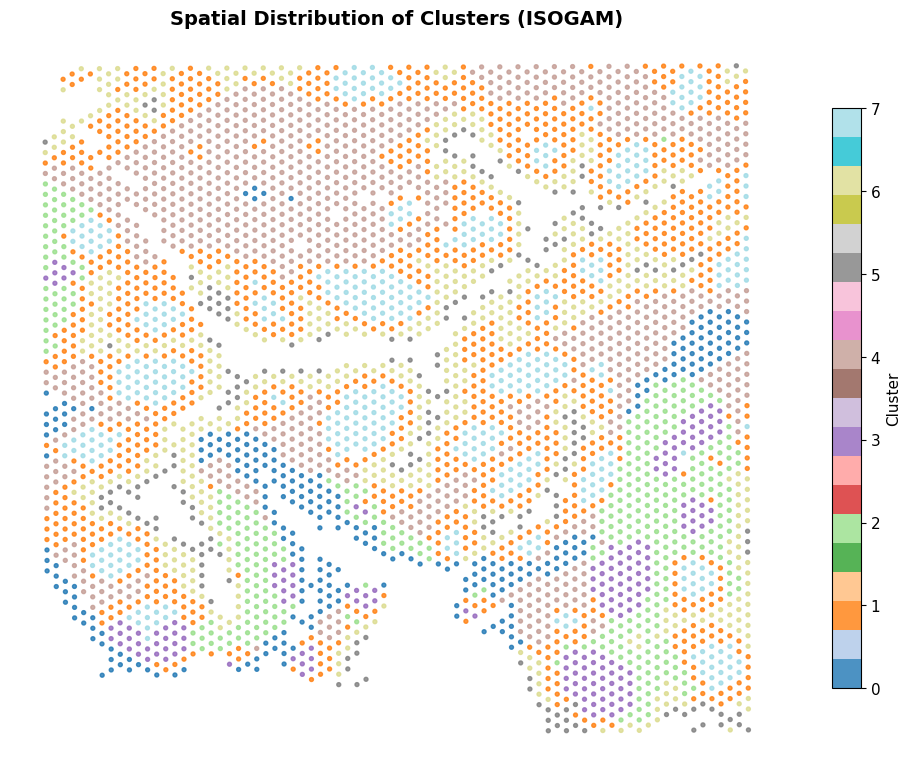

✓ 空间聚类图已保存


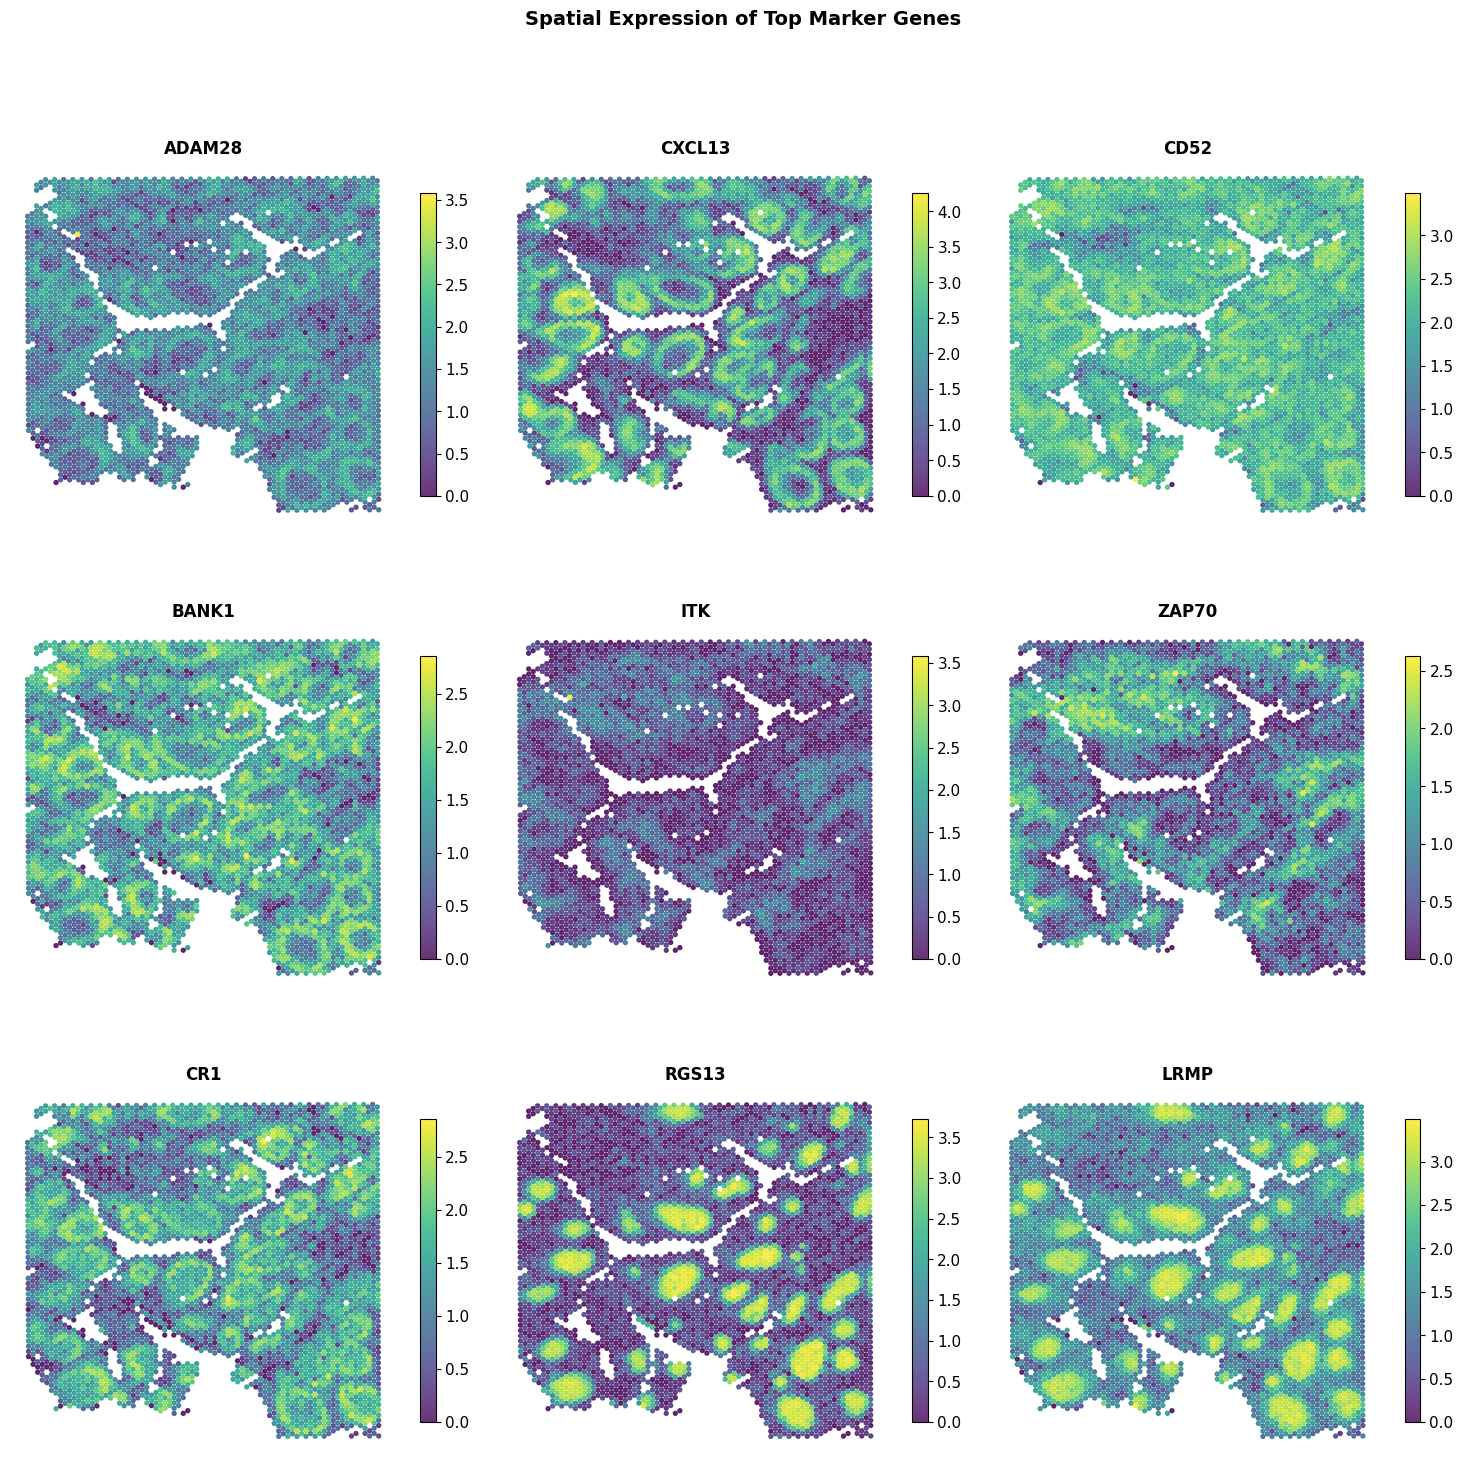

✓ 空间表达图已保存

Cell 19 完成!


In [22]:
# %% [Cell 19]: 差异表达分析（DEG热图 + 空间聚类图 + 空间表达图）
 
import seaborn as sns
from collections import Counter
 
print("=" * 70)
print("Cell 19: 差异表达分析（ISOGAM 聚类结果）")
print("=" * 70)
 
# 使用 ISOGAM_n8 seed=100 的聚类结果
isogam_run = next((r for r in ablation_results
                   if r['config_name'] == 'ISOGAM_n8' and
                      r['status'] == 'success' and r['seed'] == 100), None)
if isogam_run is None:
    print("⚠ 未找到结果，跳过Cell 19")
else:
    clusters_deg = isogam_run['clusters']
 
    # 准备 AnnData
    rna_adata = sc.read_h5ad(os.path.join(DATA_PATH, 'rna.h5ad'))
    rna_adata.var_names_make_unique()
    rna_adata.obs['cluster'] = pd.Categorical(clusters_deg.astype(str))
    x_coord = locs['4'].values
    y_coord = locs['5'].values
    rna_adata.obsm['spatial'] = np.column_stack([x_coord, y_coord])
    sc.pp.normalize_total(rna_adata, target_sum=1e4)
    sc.pp.log1p(rna_adata)
 
    # 过滤细胞数太少的cluster
    cluster_counts = rna_adata.obs['cluster'].value_counts()
    valid_clusters = cluster_counts[cluster_counts >= 5].index.tolist()
    rna_filt = rna_adata[rna_adata.obs['cluster'].isin(valid_clusters)].copy()
    rna_filt.var_names_make_unique()
    print(f"保留 {len(valid_clusters)}/{len(cluster_counts)} 个 cluster")
 
    sc.tl.rank_genes_groups(rna_filt, groupby='cluster', method='wilcoxon', n_genes=50)
    print("✓ DEG 分析完成")
 
    # DEG 热图
    top_clusters = cluster_counts[cluster_counts >= 5].sort_values(ascending=False).head(10).index.tolist()
    marker_genes = []
    for cl in top_clusters:
        try:
            marker_genes.extend(rna_filt.uns['rank_genes_groups']['names'][cl][:3])
        except:
            pass
    marker_genes = list(dict.fromkeys(marker_genes))
    marker_genes = [g for g in marker_genes if g in rna_filt.var_names][:25]
 
    if marker_genes:
        expr_mat = []
        for cl in top_clusters:
            sub = rna_filt[rna_filt.obs['cluster'] == cl, marker_genes].X
            if hasattr(sub, 'toarray'):
                sub = sub.toarray()
            expr_mat.append(np.mean(sub, axis=0))
        expr_df = pd.DataFrame(expr_mat, index=top_clusters, columns=marker_genes)
        expr_scaled = ((expr_df - expr_df.mean()) / expr_df.std()).fillna(0)
 
        fig, ax = plt.subplots(figsize=(14, 8))
        sns.heatmap(expr_scaled.T, cmap='viridis', center=0,
                    xticklabels=True, yticklabels=True, ax=ax,
                    cbar_kws={'label': 'Z-score'})
        ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
        ax.set_ylabel('Gene', fontsize=12, fontweight='bold')
        ax.set_title('Top DEGs per Cluster (ISOGAM, n_clusters=8)',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'deg_heatmap.svg'), bbox_inches='tight')
        plt.savefig(os.path.join(output_dir, 'deg_heatmap.pdf'), bbox_inches='tight')
        plt.show()
        print("✓ DEG热图已保存")
 
    # 空间聚类分布图
    fig, ax = plt.subplots(figsize=(10, 10))
    sc_p = ax.scatter(x_coord, y_coord, c=clusters_deg.astype(int),
                      cmap='tab20', s=8, alpha=0.8)
    ax.set_title('Spatial Distribution of Clusters (ISOGAM)', fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.axis('off')
    plt.colorbar(sc_p, ax=ax, shrink=0.6, label='Cluster')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'spatial_clusters.svg'), bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, 'spatial_clusters.pdf'), bbox_inches='tight')
    plt.show()
    print("✓ 空间聚类图已保存")
 
    # 空间表达图
    top_genes = ['ADAM28', 'CXCL13', 'CD52', 'BANK1', 'ITK', 'ZAP70', 'CR1', 'RGS13', 'LRMP']
    top_genes = [g for g in top_genes if g in rna_adata.var_names]
    if len(top_genes) == 0:
        all_top = []
        for cl in valid_clusters_deg:
            try:
                all_top.extend(rna_filt.uns['rank_genes_groups']['names'][cl][:3])
            except:
                pass
        top_genes = [g for g, _ in Counter(all_top).most_common(9)
                     if g in rna_adata.var_names]
    n_genes = min(9, len(top_genes))
    if n_genes > 0:
        fig, axes = plt.subplots(3, 3, figsize=(15, 15))
        axes = axes.flatten()
        for idx, gene in enumerate(top_genes[:n_genes]):
            ax = axes[idx]
            expr = rna_adata[:, gene].X
            if hasattr(expr, 'toarray'):
                expr = expr.toarray().flatten()
            else:
                expr = np.array(expr).flatten()
            sc_g = ax.scatter(x_coord, y_coord, c=expr, cmap='viridis', s=8, alpha=0.8)
            ax.set_title(gene, fontsize=12, fontweight='bold')
            ax.set_aspect('equal')
            ax.axis('off')
            plt.colorbar(sc_g, ax=ax, shrink=0.6)
        for idx in range(n_genes, len(axes)):
            axes[idx].axis('off')
        plt.suptitle('Spatial Expression of Top Marker Genes',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'spatial_expression.svg'), bbox_inches='tight')
        plt.savefig(os.path.join(output_dir, 'spatial_expression.pdf'), bbox_inches='tight')
        plt.show()
        print("✓ 空间表达图已保存")
 
print("\nCell 19 完成!")

Cell 20: RNA-蛋白一致性分析（ISOGAM 聚类）


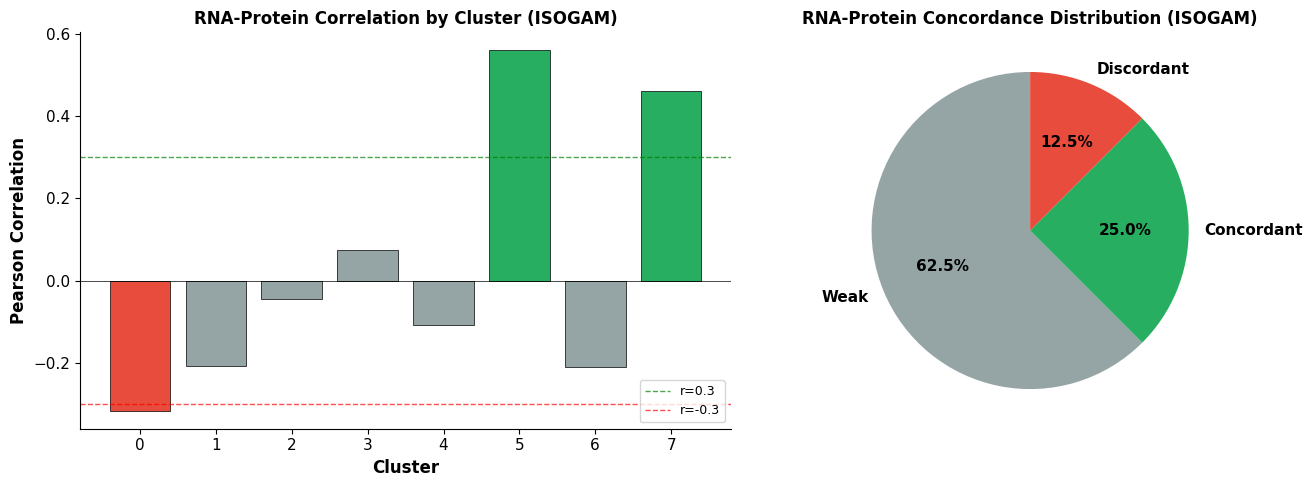

✓ RNA-蛋白一致性图已保存
  Concordant: 2/8 clusters (25.0%)
  均值相关系数: 0.026

Cell 20 完成!


In [23]:
# %% [Cell 20]: RNA-蛋白一致性分析
 
from scipy.stats import pearsonr
 
print("=" * 70)
print("Cell 20: RNA-蛋白一致性分析（ISOGAM 聚类）")
print("=" * 70)
 
if isogam_run is None:
    print("⚠ 未找到 ISOGAM 结果，跳过")
else:
    clusters_corr = isogam_run['clusters']
 
    protein_adata = sc.read_h5ad(os.path.join(DATA_PATH, 'protein.h5ad'))
    sc.pp.normalize_total(protein_adata, target_sum=1e4)
    sc.pp.log1p(protein_adata)
 
    rna_adata_corr = sc.read_h5ad(os.path.join(DATA_PATH, 'rna.h5ad'))
    sc.pp.normalize_total(rna_adata_corr, target_sum=1e4)
    sc.pp.log1p(rna_adata_corr)
 
    corr_results = []
    for cluster_id in np.unique(clusters_corr):
        mask = clusters_corr == cluster_id
        if np.sum(mask) < 10:
            continue
        rna_c = rna_adata_corr[mask, :].X
        pro_c = protein_adata[mask, :].X
        if hasattr(rna_c, 'toarray'): rna_c = rna_c.toarray()
        if hasattr(pro_c, 'toarray'): pro_c = pro_c.toarray()
        rna_mean = np.mean(rna_c, axis=1)
        pro_mean = np.mean(pro_c, axis=1)
        if np.std(rna_mean) > 0 and np.std(pro_mean) > 0:
            corr, pval = pearsonr(rna_mean, pro_mean)
        else:
            corr, pval = 0, 1
        concordance = 'Concordant' if corr > 0.3 else ('Discordant' if corr < -0.3 else 'Weak')
        corr_results.append({'cluster': cluster_id, 'n_cells': int(np.sum(mask)),
                              'pearson_r': corr, 'p_value': pval, 'concordance': concordance})
 
    corr_df = pd.DataFrame(corr_results)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    # 左图：相关性柱状图
    ax1 = axes[0]
    bar_colors_corr = ['#27ae60' if r > 0.3 else ('#e74c3c' if r < -0.3 else '#95a5a6')
                       for r in corr_df['pearson_r']]
    ax1.bar(range(len(corr_df)), corr_df['pearson_r'],
            color=bar_colors_corr, edgecolor='black', linewidth=0.5)
    ax1.axhline(y=0, color='black', linewidth=0.5)
    ax1.axhline(y=0.3,  color='green', linestyle='--', linewidth=1, alpha=0.7, label='r=0.3')
    ax1.axhline(y=-0.3, color='red',   linestyle='--', linewidth=1, alpha=0.7, label='r=-0.3')
    ax1.set_xlabel('Cluster', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Pearson Correlation', fontsize=12, fontweight='bold')
    ax1.set_title('RNA-Protein Correlation by Cluster (ISOGAM)', fontsize=12, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
 
    # 右图：一致性饼图
    ax2 = axes[1]
    concordance_counts = corr_df['concordance'].value_counts()
    pie_colors_corr = {'Concordant': '#27ae60', 'Discordant': '#e74c3c', 'Weak': '#95a5a6'}
    ax2.pie(concordance_counts.values,
            labels=concordance_counts.index,
            colors=[pie_colors_corr.get(c, '#95a5a6') for c in concordance_counts.index],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax2.set_title('RNA-Protein Concordance Distribution (ISOGAM)',
                  fontsize=12, fontweight='bold')
 
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'rna_protein_correlation.svg'), bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, 'rna_protein_correlation.pdf'), bbox_inches='tight')
    plt.show()
 
    corr_df.to_csv(os.path.join(output_dir, 'rna_protein_correlation.csv'), index=False)
    print(f"✓ RNA-蛋白一致性图已保存")
    concordant = corr_df[corr_df['concordance'] == 'Concordant']
    print(f"  Concordant: {len(concordant)}/{len(corr_df)} clusters "
          f"({len(concordant)/len(corr_df)*100:.1f}%)")
    print(f"  均值相关系数: {corr_df['pearson_r'].mean():.3f}")
 
print("\nCell 20 完成!")